# Chapter 3a -- ESG risk premia, factor models, and ESG-tilted minimum variance

Translated from the ESG-and-cost-of-debt, factor-model, and Markowitz
mean-variance scripts of `HSF/3. ESG Investing/*.m` (Roncalli, *Handbook
of Sustainable Finance*): `chap3_cost_of_debt1/3/4/6.m`,
`chap3_factor1a-4.m`, and `chap3_markowitz_param1.m`/`chap3_markowitz1-8.m`
(18 scripts).

The rest of the chapter -- the Pastor-Stambaugh and Pedersen-Fitzgibbons-
Pomorski ESG asset-pricing/portfolio models, tracking error, and the
performance-measurement scripts (bond/equity indices, factor and
optimized-portfolio backtests, sorted-portfolio analysis) -- is planned
for follow-up notebooks (`03b`, `03c`, ...).

**Two scripts are skipped.** `chap3_cost_of_debt5a.m`/`5b.m` run a
LASSO-based variable-selection regression of green-bond spreads against a
panel of E/S/G thematic variables (`Data/Panel_Data_H.mat`,
`Data/Select_Data.mat`, `Results/Selection_lasso_H.mat`, ...) -- real,
presumably proprietary rating-provider panel data that isn't shipped in
this repository (no `Panel_Data_*`, `Select_Data`, or `Results/` files
exist under `HSF/3. ESG Investing/Data/`). Rather than fabricate a
substitute dataset, this notebook omits that section entirely -- the same
policy already applied to the un-ported `hsf/cdp_filter.m` (see
`quanttoolbox.sustainable_finance.esg`'s module docstring).

Most of this notebook's computation is already in `quanttoolbox`:
`quanttoolbox.portfolio.mean_variance` (`mvo_portfolio`, `mvo_frontier`,
`mvo_target_portfolio`, `minvar_portfolio`) and
`quanttoolbox.sustainable_finance.esg` (`esg_beta_star`,
`esg_minimum_variance`) -- ported from the shared `hsf`/`rpb` MATLAB
toolbox functions these scripts call directly. This notebook applies
those functions to the book's worked examples rather than re-deriving
the underlying optimization.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quanttoolbox.portfolio.mean_variance import (
    minvar_portfolio, mvo_frontier, mvo_portfolio, mvo_target_portfolio,
)
from quanttoolbox.sustainable_finance.esg import esg_beta_star, esg_minimum_variance

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def corr_from_lower_triangle(values, n):
    # Build a symmetric n x n correlation matrix from its lower-triangular
    # entries listed row by row, e.g. [1, r21, 1, r31, r32, 1, ...]
    # (MATLAB/GAUSS `xpnd` convention used throughout the .m source).
    corr = np.eye(n)
    it = iter(values)
    for i in range(n):
        for j in range(i + 1):
            v = next(it)
            corr[i, j] = corr[j, i] = v
    return corr


## 1. ESG and the cost of debt

From `chap3_cost_of_debt1.m`, `chap3_cost_of_debt3.m`/`4.m`, and
`chap3_cost_of_debt6.m` -- three small, self-contained illustrations of
how an ESG score is hypothesized to relate to a firm's cost of debt.


### 1.1 Average ESG score by credit rating

From `chap3_cost_of_debt1.m`. A stylized illustration: firms with better
credit ratings tend to have higher average ESG scores.


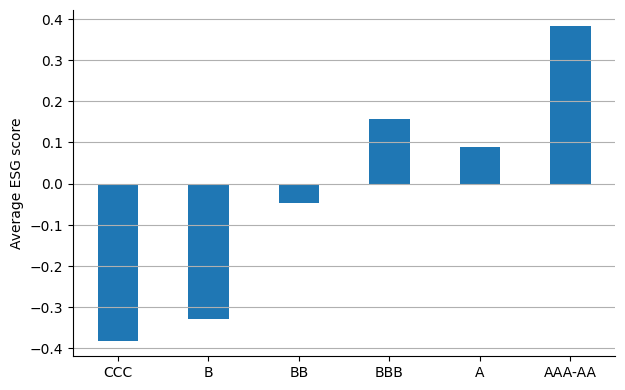

In [2]:
ratings = ["CCC", "B", "BB", "BBB", "A", "AAA-AA"]
avg_esg_score = [-0.381, -0.328, -0.048, 0.156, 0.090, 0.384]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(ratings, avg_esg_score, width=0.45, color="tab:blue")
ax.set_ylabel("Average ESG score")
ax.grid(axis="y")
plt.show()


### 1.2 A cost-of-debt sensitivity model

From `chap3_cost_of_debt3.m`/`chap3_cost_of_debt4.m`. A simple model for
how the cost of debt $\mathcal{C}_D$ responds to an ESG score:
$\mathcal{C}_D(\text{Score}) = \mathcal{C}_0\, e^{\hat\beta\, \text{Score}}$,
for a base cost of debt $\mathcal{C}_0 = 4\%$ and a range of sensitivities
$\hat\beta$. A more negative $\hat\beta$ means a better ESG score buys a
bigger reduction in borrowing cost. `chap3_cost_of_debt4.m` is a
one-line duplicate of `chap3_cost_of_debt3.m`'s closing calculation, so
both are covered by the single example below.


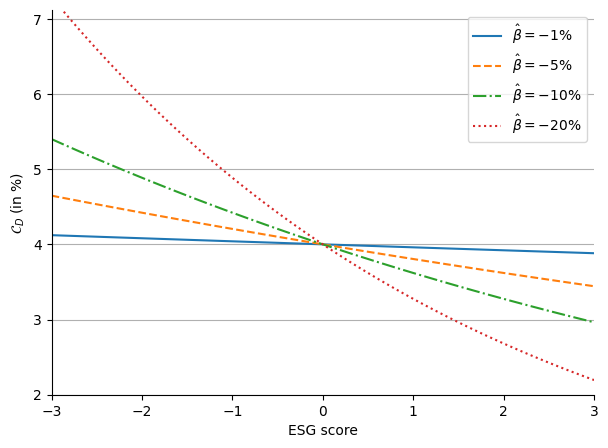

In [3]:
C0 = 0.04
score = np.linspace(-3, 3, 101)
betas = [-0.01, -0.05, -0.10, -0.20]

fig, ax = plt.subplots(figsize=(7, 5))
for beta, ls in zip(betas, ["-", "--", "-.", ":"]):
    C_D = C0 * np.exp(beta * score)
    ax.plot(score, 100 * C_D, ls, lw=1.5, label=rf"$\hat\beta = {int(100*beta)}\%$")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("ESG score")
ax.set_ylabel(r"$\mathcal{C}_D$ (in %)")
ax.set_xlim(-3, 3)
ax.set_ylim(2, 7.12)
ax.grid(axis="y")
ax.legend(fontsize=10)
plt.show()


In [4]:
# Basis-point saving in the cost of debt from moving an ESG score from -2 to +1.
C0, beta = 0.04, -0.03
score1, score2 = -2, 1
saving_bps = 10000 * C0 * (np.exp(beta * score1) - np.exp(beta * score2))
print(f"Cost-of-debt saving from Score {score1} -> {score2}: {saving_bps:.1f} bps")


Cost-of-debt saving from Score -2 -> 1: 36.6 bps


### 1.3 ESG rating and prediction accuracy

From `chap3_cost_of_debt6.m`. How well each ESG pillar (E, S, G) --
and the combined ESG score -- predicts a firm's actual credit rating,
by rating bucket.


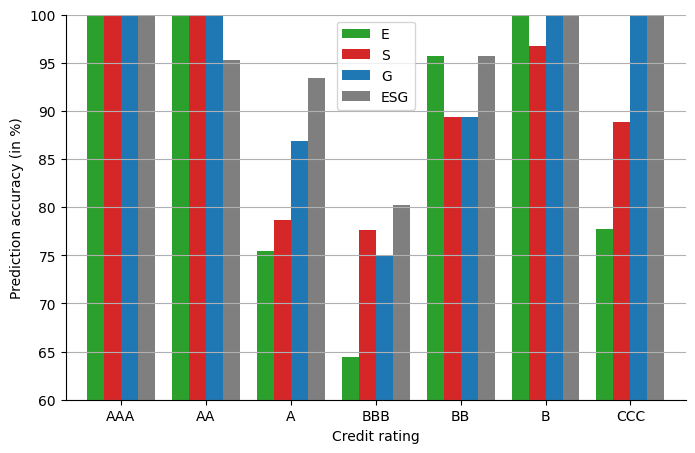

In [5]:
ratings = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]
accuracy = pd.DataFrame({
    "E": [100.00, 100.00, 75.41, 64.47, 95.74, 100.00, 77.77],
    "S": [100.00, 100.00, 78.69, 77.63, 89.36, 96.77, 88.89],
    "G": [100.00, 100.00, 86.89, 75.00, 89.36, 100.00, 100.00],
    "ESG": [100.00, 95.34, 93.44, 80.26, 95.74, 100.00, 100.00],
}, index=ratings)

ax = accuracy.plot.bar(figsize=(8, 5), color=["tab:green", "tab:red", "tab:blue", "tab:gray"], width=0.8)
ax.set_xlabel("Credit rating")
ax.set_ylabel("Prediction accuracy (in %)")
ax.set_ylim(60, 100)
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.show()


## 2. One- and two-factor ESG risk models

From `chap3_factor1a.m`-`chap3_factor4.m`. A simple structural risk
model: asset returns load on a market factor (loading $\beta$,
volatility $\sigma_m$) plus, in the two-factor version, an ESG factor
(loading $\beta^{\text{esg}}$, volatility $\sigma_{\text{esg}}$), on top
of idiosyncratic risk $\tilde\sigma_i$:

$$\Sigma = \beta\beta^\top \sigma_m^2 + \beta^{\text{esg}}(\beta^{\text{esg}})^\top \sigma_{\text{esg}}^2 + \mathrm{diag}(\tilde\sigma_i^2)$$

All five assets and their factor loadings are the book's own illustrative
numbers -- no external data.


### 2.1 One-factor covariance and its Sherman-Morrison-Woodbury inverse

From `chap3_factor1a.m`. Inverting an $n\times n$ covariance matrix
built from a single factor is cheap in closed form via
Sherman-Morrison-Woodbury, without ever inverting the full $n\times n$
matrix: $\Sigma^{-1} = D^{-1} - \dfrac{\sigma_m^2}{1+\sigma_m^2\,(\beta^\top
D^{-1}\beta)}\, (D^{-1}\beta)(D^{-1}\beta)^\top$.


In [6]:
beta = np.array([0.9, 0.8, 1.2, 0.7, 1.3])
sigma_m = 0.25
sigma_tilde = np.array([0.04, 0.12, 0.05, 0.08, 0.05])

sigma2_m = sigma_m**2
D = np.diag(sigma_tilde**2)
Sigma = np.outer(beta, beta) * sigma2_m + D

vol = np.sqrt(np.diag(Sigma))
rho = Sigma / np.outer(vol, vol)
print("Volatility (%) and correlation matrix:")
display(pd.DataFrame(100 * rho, columns=[f"A{i+1}" for i in range(5)],
                      index=[f"A{i+1}" for i in range(5)]).round(2))
print("vol (%):", (100 * vol).round(2))

inv_Sigma = np.linalg.inv(Sigma)

beta_tilde = beta / sigma_tilde**2
inv_Sigma_smw = np.linalg.inv(D) - sigma2_m / (1 + sigma2_m * (beta @ beta_tilde)) * np.outer(beta_tilde, beta_tilde)

delta = np.max(np.abs(inv_Sigma - inv_Sigma_smw))
print(f"max|inv(Sigma) - SMW formula| = {delta:.2e}")


Volatility (%) and correlation matrix:


,A1,A2,A3,A4,A5
A1,100.00,84.43,97.12,89.54,97.31
A2,84.43,100.00,84.58,77.99,84.75
A3,97.12,84.58,100.00,89.71,97.49
A4,89.54,77.99,89.71,100.00,89.89
A5,97.31,84.75,97.49,89.89,100.00


vol (%): [22.85 23.32 30.41 19.24 32.88]
max|inv(Sigma) - SMW formula| = 2.16e-12


### 2.2 Two-factor covariance and its SMW inverse

From `chap3_factor1b.m`. The same idea extended to two factors (market
and ESG); the closed-form inverse is more involved but still avoids a
direct $n\times n$ inversion.


In [7]:
beta = np.array([0.9, 0.8, 1.2, 0.7, 1.3])
sigma_m = 0.25
beta_esg = np.array([-0.5, 0.7, 0.2, 0.9, -0.3])
sigma_esg = 0.10
sigma_tilde = np.array([0.04, 0.12, 0.05, 0.08, 0.05])

sigma2_m, sigma2_esg = sigma_m**2, sigma_esg**2
sigma2_m_esg = (sigma_m * sigma_esg) ** 2
D = np.diag(sigma_tilde**2)

Sigma = np.outer(beta, beta) * sigma2_m + np.outer(beta_esg, beta_esg) * sigma2_esg + D
inv_Sigma = np.linalg.inv(Sigma)

beta_tilde = beta / sigma_tilde**2
beta_esg_tilde = beta_esg / sigma_tilde**2

varphi_m = beta @ beta_tilde
varphi_esg = beta_esg @ beta_esg_tilde
varphi_m_esg = beta @ beta_esg_tilde

omega0 = 1 + sigma2_m * varphi_m + sigma2_esg * varphi_esg + \
    sigma2_m_esg * (varphi_m * varphi_esg - varphi_m_esg**2)
omega1 = sigma2_m * (1 + sigma2_esg * varphi_esg) / omega0
omega2 = sigma2_esg * (1 + sigma2_m * varphi_m) / omega0
omega3 = sigma2_m_esg * varphi_m_esg / omega0

inv_M = (omega1 * np.outer(beta_tilde, beta_tilde) + omega2 * np.outer(beta_esg_tilde, beta_esg_tilde)
         - omega3 * (np.outer(beta_esg_tilde, beta_tilde) + np.outer(beta_tilde, beta_esg_tilde)))
inv_Sigma_smw = np.linalg.inv(D) - inv_M

delta = np.max(np.abs(inv_Sigma - inv_Sigma_smw))
print(f"max|inv(Sigma) - SMW formula| = {delta:.2e}")


max|inv(Sigma) - SMW formula| = 8.95e-13


### 2.3 Does the ESG factor raise or lower pairwise correlations?

From `chap3_factor2.m`. Comparing the implied correlation matrix under
the CAPM (market factor only) against the two-factor (market + ESG)
model -- wherever the ESG factor loadings share the same sign for two
assets, adding it pushes their correlation up; opposite signs push it
down.


In [8]:
beta = np.array([0.9, 0.8, 1.2, 0.7, 1.3])
sigma_m = 0.25
beta_esg = np.array([-0.5, 0.7, 0.2, 0.9, -0.3])
sigma_esg = 0.10
sigma_tilde = np.array([0.04, 0.12, 0.05, 0.08, 0.05])
D = np.diag(sigma_tilde**2)

Sigma_capm = np.outer(beta, beta) * sigma_m**2 + D
vol_capm = np.sqrt(np.diag(Sigma_capm))
rho_capm = Sigma_capm / np.outer(vol_capm, vol_capm)

Sigma_esg = np.outer(beta, beta) * sigma_m**2 + np.outer(beta_esg, beta_esg) * sigma_esg**2 + D
vol_esg = np.sqrt(np.diag(Sigma_esg))
rho_esg = Sigma_esg / np.outer(vol_esg, vol_esg)

higher = pd.DataFrame(np.where(rho_esg > rho_capm, "+", "").astype(object),
                       columns=[f"A{i+1}" for i in range(5)], index=[f"A{i+1}" for i in range(5)])
print("Where two-factor correlation exceeds CAPM correlation:")
display(higher)


Where two-factor correlation exceeds CAPM correlation:


,A1,A2,A3,A4,A5
A1,+,,,,
A2,,,,+,
A3,,,,,
A4,,+,,,
A5,,,,,+


### 2.4-2.5 ESG-tilted minimum-variance portfolios

From `chap3_factor3.m`/`chap3_factor4.m`. For each of two parameter
sets, four minimum-variance portfolios are compared: unconstrained CAPM
minvar, ESG-tilted minvar (`esg_minimum_variance`, ESG loadings zeroed
out so it collapses to the CAPM case), long-only CAPM minvar restricted
to its active constituents, and the same ESG tilt restricted to that
same active set -- then the whole comparison is repeated for the
two-factor (market + ESG) covariance. Uses `quanttoolbox`'s
`minvar_portfolio` (`compute_minvar_portfolio.m`) and
`esg_minimum_variance` (`compute_esg_minimum_variance.m`) directly.


In [9]:
import warnings

def factor_esg_minvar_comparison(beta, sigma_m, beta_esg, sigma_esg, sigma_tilde):
    n = len(beta)
    D = np.diag(sigma_tilde**2)

    def one_factor_set(Sigma, beta_esg_for_tilt):
        r1 = minvar_portfolio(Sigma, lb=-5.0, ub=5.0)
        # When beta_esg_for_tilt is all zero (the CAPM-only comparison), the
        # ESG beta-star hits an exact 0/0-type limit inside esg_beta_star;
        # the resulting 0/inf term still evaluates to the correct 0 (matching
        # the plain minvar case below), so the RuntimeWarning is expected and
        # harmless -- silenced here rather than papered over with a branch.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            r2 = esg_minimum_variance(beta, sigma_m, beta_esg_for_tilt, sigma_esg, sigma_tilde)
        r3 = minvar_portfolio(Sigma, lb=0.0, ub=1.0)
        active = (r3.weights > 0.001).astype(float)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            r4 = esg_minimum_variance(beta, sigma_m, beta_esg_for_tilt, sigma_esg, sigma_tilde, e=active)
        table = pd.DataFrame({
            "beta": beta, "minvar (unc.)": 100 * r1.weights, "ESG-tilt (unc.)": 100 * r2.x,
            "minvar (long-only)": 100 * r3.weights, "ESG-tilt (active set)": 100 * r4.x,
        })
        vols = pd.Series({"minvar (unc.)": 100 * r1.volatility, "ESG-tilt (unc.)": 100 * r2.sigma_x,
                           "minvar (long-only)": 100 * r3.volatility, "ESG-tilt (active set)": 100 * r4.sigma_x})
        return table, vols, r2.beta_star, r4.beta_star

    Sigma_capm = np.outer(beta, beta) * sigma_m**2 + D
    table_capm, vol_capm, bstar2, bstar4 = one_factor_set(Sigma_capm, 0.0 * beta_esg)

    Sigma_2f = np.outer(beta, beta) * sigma_m**2 + np.outer(beta_esg, beta_esg) * sigma_esg**2 + D
    table_2f, vol_2f, bstar2_2f, bstar4_2f = one_factor_set(Sigma_2f, beta_esg)

    return table_capm, vol_capm, table_2f, vol_2f


In [10]:
beta = np.array([0.9, 0.8, 1.2, 0.7, 1.3])
sigma_m = 0.25
beta_esg = np.array([-0.5, 0.7, 0.2, 0.9, -0.3])
sigma_esg = 0.10
sigma_tilde = np.array([0.04, 0.12, 0.05, 0.08, 0.05])

table_capm, vol_capm, table_2f, vol_2f = factor_esg_minvar_comparison(
    beta, sigma_m, beta_esg, sigma_esg, sigma_tilde)

print("Parameter set #1 -- CAPM covariance:")
display(table_capm.round(2))
print("Portfolio volatility (%):")
display(vol_capm.round(2))
print("\nParameter set #1 -- two-factor covariance:")
display(table_2f.round(2))
print("Portfolio volatility (%):")
display(vol_2f.round(2))


Parameter set #1 -- CAPM covariance:


,beta,minvar (unc.),ESG-tilt (unc.),minvar (long-only),ESG-tilt (active set)
0,0.9,147.33,147.33,-0.00,0.00
1,0.8,24.67,24.67,9.45,9.45
2,1.2,-49.19,-49.19,-0.00,0.00
3,0.7,74.20,74.20,90.55,90.55
4,1.3,-97.01,-97.01,-0.00,0.00


Portfolio volatility (%):


minvar (unc.)            11.45
ESG-tilt (unc.)          11.45
minvar (long-only)       19.19
ESG-tilt (active set)    19.19
dtype: float64


Parameter set #1 -- two-factor covariance:


,beta,minvar (unc.),ESG-tilt (unc.),minvar (long-only),ESG-tilt (active set)
0,0.9,166.55,166.55,33.54,33.54
1,0.8,21.37,21.37,1.46,1.46
2,1.2,-58.80,-58.80,0.00,0.00
3,0.7,65.06,65.06,64.99,64.99
4,1.3,-94.18,-94.18,0.00,0.00


Portfolio volatility (%):


minvar (unc.)            11.54
ESG-tilt (unc.)          11.54
minvar (long-only)       20.40
ESG-tilt (active set)    20.40
dtype: float64

In [11]:
beta = np.array([0.7, 0.8, 0.9, 1.2, 1.5])
sigma_m = 0.25
beta_esg = np.array([-0.5, -0.7, -0.5, 0.9, 1.3])
sigma_esg = 0.10
sigma_tilde = np.array([0.10, 0.08, 0.03, 0.05, 0.04])

table_capm, vol_capm, table_2f, vol_2f = factor_esg_minvar_comparison(
    beta, sigma_m, beta_esg, sigma_esg, sigma_tilde)

print("Parameter set #2 -- CAPM covariance:")
display(table_capm.round(2))
print("Portfolio volatility (%):")
display(vol_capm.round(2))
print("\nParameter set #2 -- two-factor covariance:")
display(table_2f.round(2))
print("Portfolio volatility (%):")
display(vol_2f.round(2))


Parameter set #2 -- CAPM covariance:


,beta,minvar (unc.),ESG-tilt (unc.),minvar (long-only),ESG-tilt (active set)
0,0.7,26.21,26.21,66.96,66.96
1,0.8,32.17,32.17,33.04,33.04
2,0.9,166.32,166.32,0.00,0.00
3,1.2,-7.55,-7.55,0.00,0.00
4,1.5,-117.15,-117.15,0.00,0.00


Portfolio volatility (%):


minvar (unc.)             8.10
ESG-tilt (unc.)           8.10
minvar (long-only)       19.69
ESG-tilt (active set)    19.69
dtype: float64


Parameter set #2 -- two-factor covariance:


,beta,minvar (unc.),ESG-tilt (unc.),minvar (long-only),ESG-tilt (active set)
0,0.7,57.34,57.34,73.46,73.46
1,0.8,19.57,19.57,26.54,26.54
2,0.9,10.31,10.31,0.00,0.00
3,1.2,130.35,130.35,0.00,0.00
4,1.5,-117.58,-117.58,0.00,0.00


Portfolio volatility (%):


minvar (unc.)            17.21
ESG-tilt (unc.)          17.21
minvar (long-only)       20.47
ESG-tilt (active set)    20.47
dtype: float64

## 3. Markowitz mean-variance portfolios

From `chap3_markowitz_param1.m` and `chap3_markowitz1.m`-`chap3_markowitz8.m`.
A review of standard mean-variance portfolio theory -- the efficient
frontier, the tangency portfolio and capital market line, beta
decomposition of risk premia -- using two illustrative five- and
four-asset parameter sets. This sets up the vocabulary (`gamma` the
risk-aversion parameter, the tangency portfolio, beta/pi/alpha
decomposition) that the ESG-specific Pastor-Stambaugh and Pedersen models
in the next notebook build directly on top of. Uses `quanttoolbox`'s
`mvo_portfolio`/`mvo_frontier`/`mvo_target_portfolio`
(`compute_mvo_portfolio.m`).


In [12]:
def markowitz_param1(mvo_param=1):
    if mvo_param == 1:
        mu = np.array([0.05, 0.07, 0.06, 0.10, 0.08])
        sigma = np.array([0.18, 0.20, 0.22, 0.25, 0.30])
        corr = corr_from_lower_triangle(
            [1.00,
             0.70, 1.00,
             0.20, 0.30, 1.00,
             -0.30, 0.20, 0.10, 1.00,
             0.00, 0.00, 0.00, 0.00, 1.00], 5)
        r = 0.03
    else:
        mu = np.array([0.05, 0.06, 0.08, 0.06])
        sigma = np.array([0.15, 0.20, 0.25, 0.30])
        corr = corr_from_lower_triangle(
            [1.00,
             0.10, 1.00,
             0.40, 0.70, 1.00,
             0.50, 0.40, 0.80, 1.00], 4)
        r = 0.015
    Sigma = corr * np.outer(sigma, sigma)
    return mu, sigma, Sigma, r


mu, sigma, Sigma, r = markowitz_param1(1)
n = len(mu)


### 3.1 The efficient frontier, and target-return / target-volatility portfolios

From `chap3_markowitz1.m`.


In [13]:
gammas_table = [0, 0.10, 0.20, 0.50, 1.00, 5.00]
frontier_pts = mvo_frontier(mu, Sigma, gammas_table, lb=-10.0, ub=10.0)
pd.DataFrame({
    "gamma": gammas_table,
    **{f"A{i+1}": [100 * p.weights[i] for p in frontier_pts] for i in range(n)},
    "mu (%)": [100 * p.expected_return for p in frontier_pts],
    "sigma (%)": [100 * p.volatility for p in frontier_pts],
}).round(2)


,gamma,A1,A2,A3,A4,A5,mu (%),sigma (%)
0,0.0,66.35,-28.52,15.31,34.85,12.02,6.69,10.40
1,0.1,58.25,-22.67,13.30,37.65,13.48,6.97,10.53
2,0.2,50.14,-16.82,11.30,40.44,14.94,7.25,10.93
3,0.5,25.84,0.74,5.28,48.82,19.32,8.09,13.35
4,1.0,-14.67,30.00,-4.74,62.78,26.62,9.49,19.71
5,5.0,-338.72,264.12,-84.93,174.50,85.03,20.71,84.38


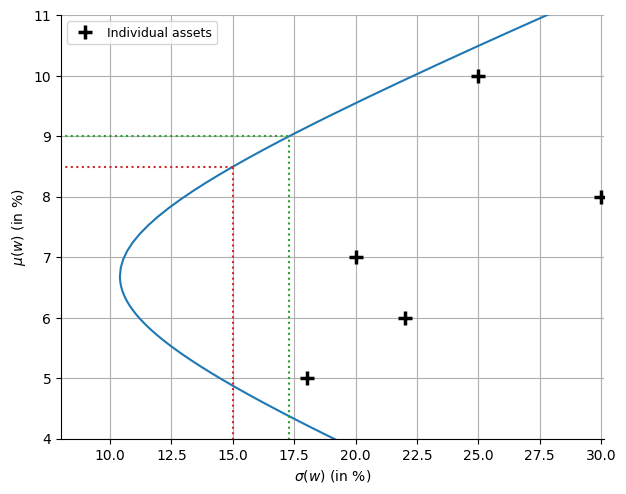

Target sigma=15%: mu=8.50%, gamma=0.645
Target mu=9%:     sigma=17.30%, gamma=0.825


In [14]:
gammas_curve = np.concatenate([np.arange(-1.0, 0, 0.01), np.arange(0, 2.0 + 0.05, 0.05)])
curve = mvo_frontier(mu, Sigma, gammas_curve, lb=-10.0, ub=10.0)
all_mu_x = np.array([p.expected_return for p in curve])
all_sigma_x = np.array([p.volatility for p in curve])

target_mu = mvo_target_portfolio(mu, Sigma, 0.09, problem="mu", lb=-10.0, ub=10.0)[0]
target_sigma = mvo_target_portfolio(mu, Sigma, 0.15, problem="sigma", lb=-10.0, ub=10.0)[0]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(100 * all_sigma_x, 100 * all_mu_x, "-", color="tab:blue", lw=1.5)
ax.plot([100 * target_sigma.volatility] * 2, [0, 100 * target_sigma.expected_return], ":", color="tab:red")
ax.plot([0, 100 * target_sigma.volatility], [100 * target_sigma.expected_return] * 2, ":", color="tab:red")
ax.plot([100 * target_mu.volatility] * 2, [0, 100 * target_mu.expected_return], ":", color="tab:green")
ax.plot([0, 100 * target_mu.volatility], [100 * target_mu.expected_return] * 2, ":", color="tab:green")
ax.plot(100 * sigma, 100 * mu, "+", color="black", markersize=10, mew=2.5, label="Individual assets")
ax.set_xlabel(r"$\sigma(w)$ (in %)")
ax.set_ylabel(r"$\mu(w)$ (in %)")
ax.set_xlim(8, 30.1)
ax.set_ylim(4, 11)
ax.grid(True)
ax.legend(fontsize=9)
plt.show()

print(f"Target sigma=15%: mu={100*target_sigma.expected_return:.2f}%, gamma={target_sigma.gamma:.3f}")
print(f"Target mu=9%:     sigma={100*target_mu.volatility:.2f}%, gamma={target_mu.gamma:.3f}")


### 3.2 Closed-form decomposition: GMV portfolio plus a self-financing overlay

From `chap3_markowitz2.m`. Any mean-variance-optimal (unconstrained)
portfolio can be written as the global minimum-variance (GMV) portfolio
plus a risk-aversion-scaled, self-financing "long-short" overlay
$x_{\text{ls}}$ (which sums to zero): $x(\gamma) = x_{\text{gmv}} +
\gamma\, x_{\text{ls}}$, with $x_{\text{gmv}} = \dfrac{\Sigma^{-1}
\mathbf{1}}{\mathbf{1}^\top \Sigma^{-1}\mathbf{1}}$ and $x_{\text{ls}}$
built from $\Sigma^{-1}\mu$ and $\Sigma^{-1}\mathbf{1}$.


In [15]:
gamma1 = 1.0
p1 = mvo_portfolio(mu, Sigma, gamma=gamma1, lb=-10.0, ub=10.0)

e = np.ones(n)
inv_Sigma = np.linalg.inv(Sigma)
x_gmv = (inv_Sigma @ e) / (e @ inv_Sigma @ e)
x_ls = ((e @ inv_Sigma @ e) * (inv_Sigma @ mu) - (e @ inv_Sigma @ mu) * (inv_Sigma @ e)) / (e @ inv_Sigma @ e)
x2 = x_gmv + gamma1 * x_ls

pd.DataFrame({"mvo_portfolio": 100 * p1.weights, "x_gmv + gamma*x_ls": 100 * x2,
              "x_gmv": 100 * x_gmv, "x_ls": 100 * x_ls})


,mvo_portfolio,x_gmv + gamma*x_ls,x_gmv,x_ls
0,-14.666511,-14.666511,66.346720,-81.013230
1,30.003872,30.003872,-28.524574,58.528446
2,-4.739107,-4.739107,15.308205,-20.047312
3,62.781545,62.781545,34.852457,27.929087
4,26.620201,26.620201,12.017192,14.603009


### 3.3 The efficient frontier under portfolio-weight constraints

From `chap3_markowitz3.m`. Adding a long-only constraint, or a $33\%$
concentration cap, shrinks the achievable frontier -- most visibly at
the low-volatility end, where the unconstrained frontier can exploit
short positions that constrained portfolios cannot.


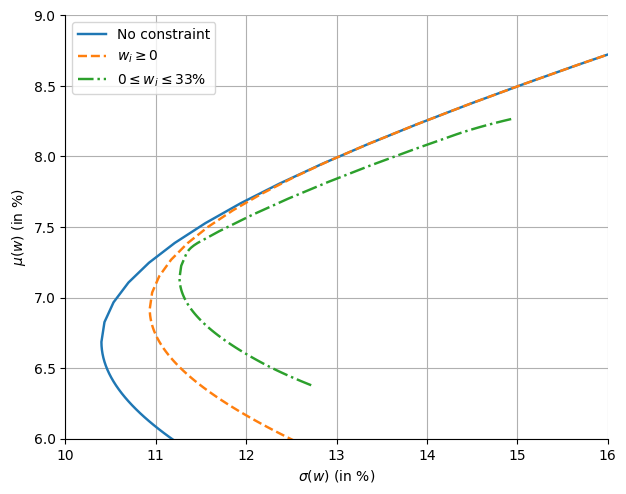

In [16]:
gammas = np.concatenate([np.arange(-0.5, 0, 0.01), np.arange(0, 1.0 + 0.05, 0.05)])

frontiers = {}
for label, lb, ub in [("No constraint", -10.0, 10.0), (r"$w_i \geq 0$", 0.0, 1.0),
                       (r"$0 \leq w_i \leq 33\%$", 0.0, 0.33)]:
    pts = mvo_frontier(mu, Sigma, gammas, lb=lb, ub=ub)
    frontiers[label] = (np.array([p.volatility for p in pts]), np.array([p.expected_return for p in pts]))

fig, ax = plt.subplots(figsize=(7, 5.5))
for (label, (s, m)), ls in zip(frontiers.items(), ["-", "--", "-."]):
    ax.plot(100 * s, 100 * m, ls, lw=1.75, label=label)
ax.set_xlabel(r"$\sigma(w)$ (in %)")
ax.set_ylabel(r"$\mu(w)$ (in %)")
ax.set_xlim(10, 16)
ax.set_ylim(6, 9)
ax.grid(True)
ax.legend(fontsize=10)
plt.show()


### 3.4 The tangency portfolio and the capital market line

From `chap3_markowitz4.m`. Adding a risk-free rate $r$ turns the
efficient frontier into a straight capital market line through
$(0, r)$ tangent to the risky-asset frontier at the tangency portfolio
$w^\ast \propto \Sigma^{-1}(\mu - r)$ -- the highest-Sharpe-ratio
portfolio of risky assets. A sub-optimal risky portfolio ($w^\star$,
target volatility 25%) is shown for comparison: its own market line has
a visibly lower slope (Sharpe ratio) than the true capital market line.


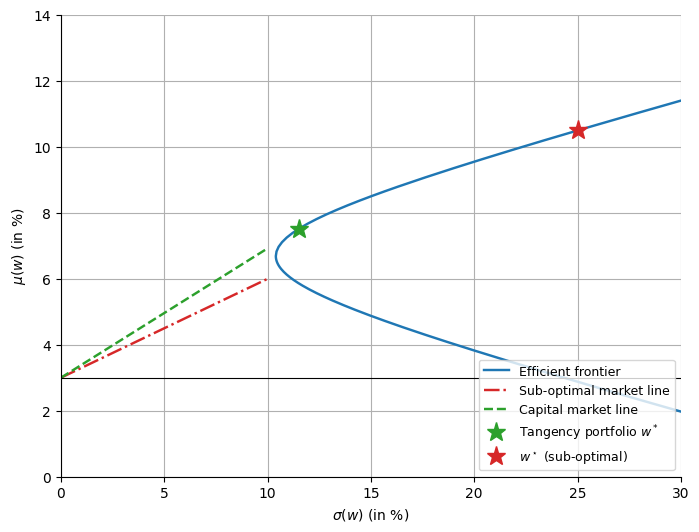

Tangency portfolio: mu=7.51%, sigma=11.50%, SR=0.392


In [17]:
gammas = np.concatenate([np.arange(-5.5, 0, 0.01), np.arange(0, 5.0 + 0.05, 0.05)])
frontier = mvo_frontier(mu, Sigma, gammas, lb=-10.0, ub=10.0)
all_sigma_x = np.array([p.volatility for p in frontier])
all_mu_x = np.array([p.expected_return for p in frontier])

sub = mvo_target_portfolio(mu, Sigma, 0.25, problem="sigma", lb=-10.0, ub=10.0)[0]
SR_sub = (sub.expected_return - r) / sub.volatility
x_line = np.linspace(0, 0.1, 401)

x_star = inv_Sigma @ (mu - r)
x_star = x_star / x_star.sum()
mu_star = x_star @ mu
sigma_star = np.sqrt(x_star @ Sigma @ x_star)
SR_star = (mu_star - r) / sigma_star

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(100 * all_sigma_x, 100 * all_mu_x, "-", color="tab:blue", lw=1.75, label="Efficient frontier")
ax.plot(100 * x_line, 100 * (r + SR_sub * x_line), "-.", color="tab:red", lw=1.75, label="Sub-optimal market line")
ax.plot(100 * x_line, 100 * (r + SR_star * x_line), "--", color="tab:green", lw=1.75, label="Capital market line")
ax.plot(100 * sigma_star, 100 * mu_star, "*", color="tab:green", markersize=14, label="Tangency portfolio $w^*$")
ax.plot(100 * sub.volatility, 100 * sub.expected_return, "*", color="tab:red", markersize=14, label=r"$w^\star$ (sub-optimal)")
ax.axhline(100 * r, color="black", lw=0.8)
ax.set_xlabel(r"$\sigma(w)$ (in %)")
ax.set_ylabel(r"$\mu(w)$ (in %)")
ax.set_xlim(0, 30)
ax.set_ylim(0, 14)
ax.grid(True)
ax.legend(fontsize=9, loc="lower right")
plt.show()

print(f"Tangency portfolio: mu={100*mu_star:.2f}%, sigma={100*sigma_star:.2f}%, SR={SR_star:.3f}")


### 3.5 Tangency portfolio weights, in detail

From `chap3_markowitz5.m`.


In [18]:
theta_star = np.degrees(np.arctan(SR_star))
pd.Series({**{f"A{i+1} weight (%)": round(100 * w, 2) for i, w in enumerate(x_star)},
           "mu (%)": round(100 * mu_star, 2), "sigma (%)": round(100 * sigma_star, 2),
           "Sharpe ratio": round(SR_star, 4), "angle (deg)": round(theta_star, 2)})


A1 weight (%)    42.570
A2 weight (%)   -11.350
A3 weight (%)     9.430
A4 weight (%)    43.050
A5 weight (%)    16.300
mu (%)            7.510
sigma (%)        11.500
Sharpe ratio      0.392
angle (deg)      21.400
dtype: float64

### 3.6 Beta decomposition of the risk premium (CAPM identity)

From `chap3_markowitz6.m`. For the tangency portfolio $w^\ast$ and any
other portfolio $y$ (each individual asset, the equal-weighted
portfolio, and the GMV portfolio here), CAPM's identity holds exactly by
construction: $\mu(y) - r = \beta_y\, \pi(w^\ast)$ where $\beta_y =
\dfrac{y^\top \Sigma w^\ast}{w^{\ast\top}\Sigma w^\ast}$ and $\pi(w^\ast)
= \mu(w^\ast) - r$.


In [19]:
pi_star = mu_star - r
w_ew = np.ones(n) / n
w_gmv = inv_Sigma @ np.ones(n)
w_gmv = w_gmv / w_gmv.sum()

candidates = np.column_stack([np.eye(n), w_ew, w_gmv])
labels = [f"A{i+1}" for i in range(n)] + ["Equal-weighted", "GMV"]

beta_y = np.array([(y @ Sigma @ x_star) / (x_star @ Sigma @ x_star) for y in candidates.T])
mu_y = candidates.T @ mu
pi_y = beta_y * pi_star

pd.DataFrame({"mu (%)": 100 * mu_y, "mu - r (%)": 100 * (mu_y - r), "beta": beta_y, "pi = beta*pi* (%)": 100 * pi_y},
             index=labels).round(3)


,mu (%),mu - r (%),beta,pi = beta*pi* (%)
A1,5.000,2.000,0.444,2.000
A2,7.000,4.000,0.887,4.000
A3,6.000,3.000,0.665,3.000
A4,10.000,7.000,1.553,7.000
A5,8.000,5.000,1.109,5.000
Equal-weighted,7.200,4.200,0.932,4.200
GMV,6.686,3.686,0.817,3.686


### 3.7 The empirical max-Sharpe long-only portfolio, and alpha

From `chap3_markowitz7.m`. Scanning long-only ($0 \le w_i \le 1$)
portfolios along the frontier for the one with the highest empirical
Sharpe ratio, then decomposing every candidate portfolio's premium into
a CAPM-implied piece ($\pi_y = \beta_y \pi(w^\ast)$) and a residual
"alpha" ($\alpha_y = \mu(y) - r - \pi_y$) relative to *this* long-only
tangency portfolio.


In [20]:
gammas = np.arange(0, 1.0 + 0.001, 0.001)
frontier = mvo_frontier(mu, Sigma, gammas, lb=0.0, ub=1.0)
sigma_x = np.array([p.volatility for p in frontier])
mu_x = np.array([p.expected_return for p in frontier])
SR_x = (mu_x - r) / sigma_x
i_max = int(np.argmax(SR_x))

w_star = frontier[i_max].weights
mu_star_lo = frontier[i_max].expected_return
sigma_star_lo = frontier[i_max].volatility
SR_star_lo = SR_x[i_max]

print(f"Long-only tangency: mu={100*mu_star_lo:.2f}%, sigma={100*sigma_star_lo:.2f}%, SR={SR_star_lo:.4f}")
display(pd.Series({f"A{i+1}": round(100 * w, 2) for i, w in enumerate(w_star)}))

pi_star_lo = mu_star_lo - r
candidates = np.column_stack([np.eye(n), w_ew, w_gmv])
beta_y = np.array([(y @ Sigma @ w_star) / (w_star @ Sigma @ w_star) for y in candidates.T])
mu_y = candidates.T @ mu
pi_y = beta_y * pi_star_lo
alpha_y = mu_y - r - pi_y

pd.DataFrame({"mu (%)": 100 * mu_y, "mu - r (%)": 100 * (mu_y - r), "beta": beta_y,
              "pi (%)": 100 * pi_y, "alpha (%)": 100 * alpha_y}, index=labels).round(3)


Long-only tangency: mu=7.63%, sigma=11.88%, SR=0.3896


A1    33.62
A2    -0.00
A3     8.79
A4    40.65
A5    16.95
dtype: float64

,mu (%),mu - r (%),beta,pi (%),alpha (%)
A1,5.000,2.000,0.432,2.000,-0.000
A2,7.000,4.000,0.970,4.491,-0.491
A3,6.000,3.000,0.648,3.000,-0.000
A4,10.000,7.000,1.512,7.000,0.000
A5,8.000,5.000,1.080,5.000,0.000
Equal-weighted,7.200,4.200,0.929,4.298,-0.098
GMV,6.686,3.686,0.766,3.546,0.140


### 3.8 Reverse optimization: implied risk aversion and implied returns

From `chap3_markowitz8.m`. Given a benchmark portfolio $w_0$ and its
(assumed) Sharpe ratio, reverse-engineer the implied risk-aversion
$\gamma_0 = \sigma(w_0)/\mathrm{SR}(w_0)$ and the vector of expected
returns $\pi_0 = \mathrm{SR}(w_0)\,\dfrac{\Sigma w_0}{\sigma(w_0)}$ that
would make $w_0$ mean-variance optimal -- the reverse-optimization step
behind Black-Litterman-style portfolio construction.


In [21]:
w0 = np.array([0.35, 0.25, 0.15, 0.15, 0.10])
SR_w0 = 0.25
sigma_w0 = np.sqrt(w0 @ Sigma @ w0)

gamma0 = sigma_w0 / SR_w0
pi0 = SR_w0 * (Sigma @ w0) / sigma_w0

print(f"sigma(w0) = {100*sigma_w0:.2f}%,  implied risk aversion gamma0 = {gamma0:.2f}")
display(pd.Series({f"A{i+1}": round(100 * p, 2) for i, p in enumerate(pi0)}, name="implied excess return (%)"))


sigma(w0) = 12.52%,  implied risk aversion gamma0 = 0.50


A1    3.36
A2    4.45
A3    2.83
A4    1.59
A5    1.80
Name: implied excess return (%), dtype: float64